In [1]:
import os
import numpy as np
from nilearn import image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns

In [2]:

foundationScores_dir = "/Users/silvycollin/Documents/GitHub/wholeBrain_narratives_MAC_MFT/text/foundationScores/"

In [3]:
# ------------------------
# Load mask data
# ------------------------

whichROI = "STG_MTG"  # STG_MTG, TPJ
whichStory = "21styear"  # tunnel, 21styear, piemanpni, forgot

base_dir = "/Users/silvycollin/Documents/research/narrativeProject/"
foundationScores_file = f"{foundationScores_dir}{whichStory}_MFT_MAC.xlsx"
foundationScores = pd.read_excel(foundationScores_file)

print(whichStory)
print(whichROI)

# Define possible paths for each ROI and story
valid_stories = {"21styear", "tunnel", "piemanpni", "forgot","bronx","black"}
valid_rois = {"TPJ", "STG_MTG"}

if whichStory not in valid_stories:
    raise ValueError(f"Unknown story: {whichStory}")
if whichROI not in valid_rois:
    raise ValueError(f"Unknown ROI: {whichROI}")

data_dir = f"{base_dir}{whichStory}/data_masks/{whichROI}/"

left_TPJ = np.load(data_dir + f"{whichROI}_refined_mask_L_3D_clean.npy")
right_TPJ = np.load(data_dir + f"{whichROI}_refined_mask_R_3D_clean.npy")

# ------------------------
# load foundation scores 
# ------------------------
#start and end column is start and end of the sentences in seconds, TR was 1.5 sec


21styear
STG_MTG


In [4]:
# foundationScoresSelect = foundationScores[["MAC_a_fairness_virtue","MAC_a_family_virtue","MAC_a_reciprocity_virtue",
#                                            "MAC_a_deference_virtue","MAC_a_property_virtue","MAC_a_group_virtue",
#                                            "MAC_a_property_virtue",
#                                            "MAC_a_fairness_vice","MAC_a_family_vice","MAC_a_reciprocity_vice",
#                                            "MAC_a_deference_vice","MAC_a_property_vice","MAC_a_group_vice",
#                                            "MAC_a_property_vice",
#                                            "MAC_a_moral_nonmoral","start","end"]]

whichFoundationScore = "MAC_a_moral_nonmoral"


In [5]:

foundationScoresSelect = foundationScores[[whichFoundationScore,"start","end"]]
foundationScoresSelect = foundationScoresSelect.copy()

# go from seconds to TRs for start and end column
foundationScoresSelect["startTR"] = foundationScoresSelect["start"] / 1.5
foundationScoresSelect["endTR"] = foundationScoresSelect["end"] / 1.5

# round to full TRs/volumes
foundationScoresSelect["startTR"] = foundationScoresSelect["startTR"].round(0).astype(int)
foundationScoresSelect["endTR"] = foundationScoresSelect["endTR"].round(0).astype(int)

# shift by 3 TRs for the HRF
foundationScoresSelect['startTR'] = foundationScoresSelect['startTR'] + 3
foundationScoresSelect['endTR'] = foundationScoresSelect['endTR'] + 3


In [6]:
# average across all voxels in the mask
left_TPJ_mean = left_TPJ.mean(axis=0)
print("check if averaging correctly, shape of output left_TPJ: ", left_TPJ_mean.shape)

right_TPJ_mean = right_TPJ.mean(axis=0)
print("check if averaging correctly, shape of output right_TPJ: ", right_TPJ_mean.shape)

# determine number of subjects
n_subjects = left_TPJ_mean.shape[1]

# pre-create the necessary columns
for s in range(n_subjects):
    foundationScoresSelect[f"left_TPJ_subj{s+1}"] = np.nan
    foundationScoresSelect[f"right_TPJ_subj{s+1}"] = np.nan

for index, row in foundationScoresSelect.iterrows():

    valueStart = int(row["startTR"])
    valueEnd = int(row["endTR"])

    for currSubj in range(n_subjects):

        # left TPJ
        col_name_leftTPJ = f"left_TPJ_subj{currSubj+1}"
        foundationScoresSelect.loc[index, col_name_leftTPJ] = left_TPJ_mean[valueStart:valueEnd+1, currSubj].mean()

        # right TPJ
        col_name_rightTPJ = f"right_TPJ_subj{currSubj+1}"
        foundationScoresSelect.loc[index, col_name_rightTPJ] = right_TPJ_mean[valueStart:valueEnd+1, currSubj].mean()

check if averaging correctly, shape of output left_TPJ:  (2249, 25)
check if averaging correctly, shape of output right_TPJ:  (2249, 25)


In [7]:
# select only the moral sentences
foundationScoresSelect_nonzero = foundationScoresSelect[foundationScoresSelect[whichFoundationScore] != 0]


In [8]:
foundationScoresSelect_nonzero = foundationScoresSelect_nonzero.drop(columns=['start', 'end', 'startTR', 'endTR'])


In [9]:
# split in left TPJ and right TPJ
foundationScoresSelect_nonzero_left = foundationScoresSelect_nonzero[[whichFoundationScore] + [col for col in foundationScoresSelect_nonzero.columns if col.startswith('left')]]
foundationScoresSelect_nonzero_right = foundationScoresSelect_nonzero[[whichFoundationScore] + [col for col in foundationScoresSelect_nonzero.columns if col.startswith('right')]]


In [10]:
# correlations
correlation_matrix_left = foundationScoresSelect_nonzero_left.corr()
correlation_matrix_right = foundationScoresSelect_nonzero_right.corr()

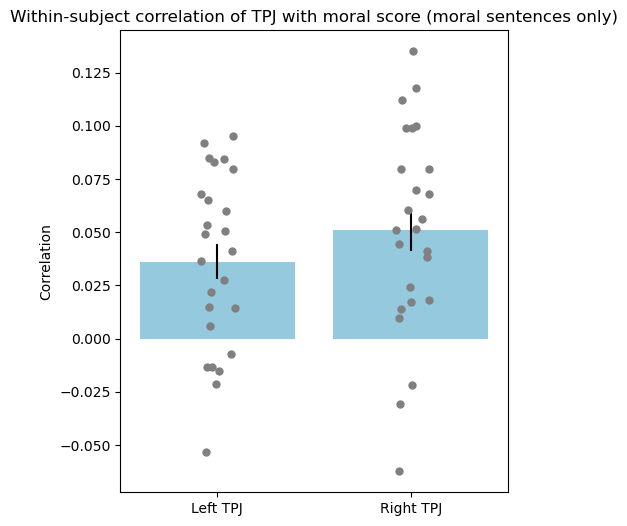

In [11]:
values_left = correlation_matrix_left[whichFoundationScore][1:] 
values_right = correlation_matrix_right[whichFoundationScore][1:] 

# Compute mean and SEM
mean_val_left = np.mean(values_left)
sem_val_left = np.std(values_left, ddof=1) / np.sqrt(len(values_left))

mean_val_right = np.mean(values_right)
sem_val_right = np.std(values_right, ddof=1) / np.sqrt(len(values_right))

# Create lists for plotting
means = [mean_val_left, mean_val_right]
sems = [sem_val_left, sem_val_right]
labels = ['Left TPJ', 'Right TPJ']

# Create the barplot
plt.figure(figsize=(5,6))
sns.barplot(x=labels, y=means, yerr=sems, color='skyblue', errorbar=None)

# Overlay individual dots
sns.stripplot(x=np.repeat(labels, [len(values_left), len(values_right)]),
              y=np.concatenate([values_left, values_right]),
              color='grey', size=6, jitter=True)

plt.ylabel('Correlation')
plt.title('Within-subject correlation of TPJ with moral score (moral sentences only)')
plt.show()


In [12]:

# One-sample t-test against 0
t_stat, p_value = stats.ttest_1samp(correlation_matrix_left[whichFoundationScore][1:] , popmean=0)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 4.358450166457073
p-value: 0.0002122968504112376


In [13]:
# One-sample t-test against 0
t_stat, p_value = stats.ttest_1samp(correlation_matrix_right[whichFoundationScore][1:] , popmean=0)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 5.276426345254243
p-value: 2.067082060442179e-05
